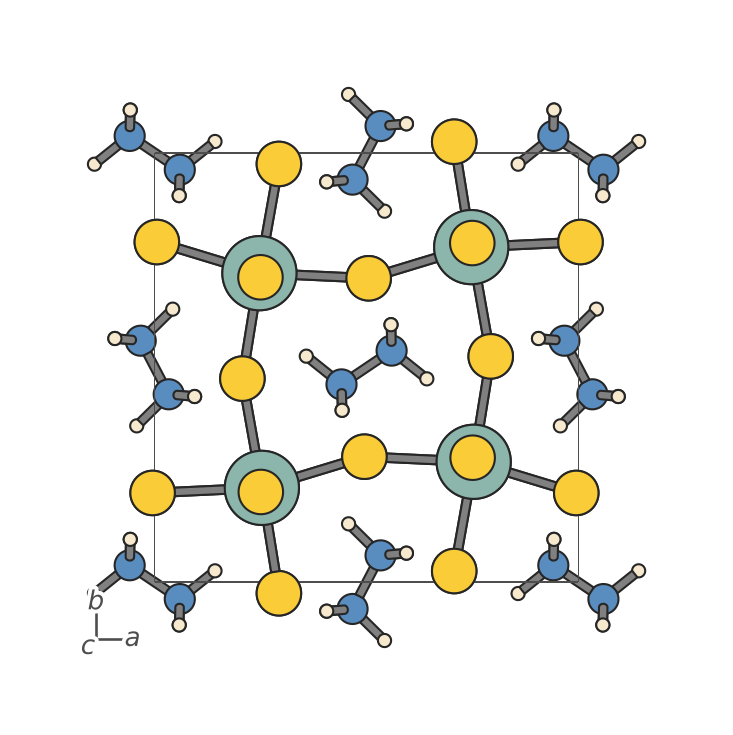

In [14]:
from hofmann import StructureScene, BondSpec, PolyhedronSpec
from pymatgen.analysis import local_env
from pathlib import Path
from monty.serialization import loadfn
from pymatgen.core import Structure

structure = Structure.from_file("../01_hzzrs3/relax-ps/CONTCAR")

vesta_cutoffs = loadfn(Path(local_env.__file__).parent / "vesta_cutoffs.yaml")

bonds = [
    BondSpec(species=('S', 'Zr'), min_length=0.0, max_length=2.9, radius=0.1, colour=0.5, complete="Zr"),
    BondSpec(species=('N', 'N'), min_length=0.0, max_length=1.9, radius=0.1, colour=0.5, recursive=True),
    BondSpec(species=('H', 'N'), min_length=0.0, max_length=1.2, radius=0.1, colour=0.5, recursive=True),
]
spec = PolyhedronSpec(
    centre="Zr",
    alpha=0.3,
    hide_bonds=True,
)
scene = StructureScene.from_pymatgen(structure, bonds,  pbc=True)
# scene = StructureScene.from_pymatgen(structure, bonds, polyhedra=[spec], pbc=True)
# scene.atom_styles["Zr"].colour = (0.5, 1.0, 0.5)
# scene.atom_styles["N"].colour = (0.0, 0.5, 1.0)
scene.atom_styles["Zr"].colour = (0.55, 0.71, 0.67)
scene.atom_styles["N"].colour = (0.35, 0.55, 0.75)
fig = scene.render_mpl(half_bonds=False)


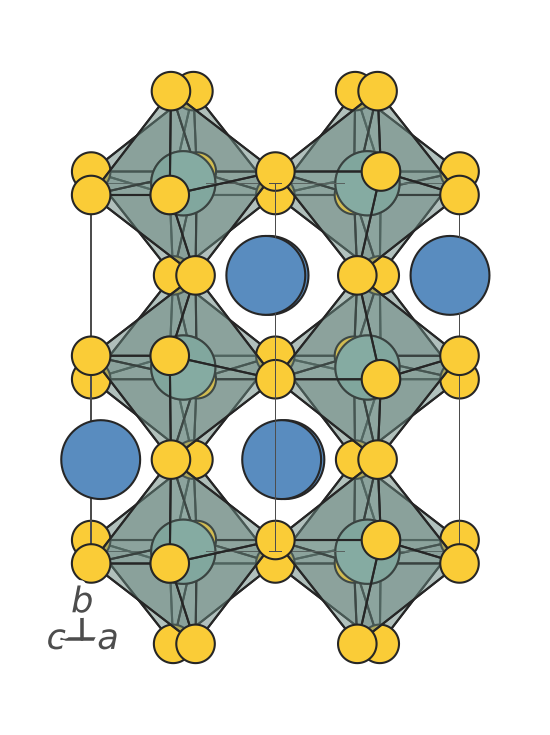

In [28]:
# %matplotlib qt

from hofmann import StructureScene, PolyhedronSpec, default_bond_specs
from pymatgen.core import Structure


structure = Structure.from_file("../relaxed-cifs/BaZrS3.cif")

bonds = [
    BondSpec(species=('S', 'Zr'), min_length=0.0, max_length=2.9, radius=0.1, colour=0.5, complete="Zr"),
]
spec = [PolyhedronSpec(centre="Zr", alpha=0.3)]
# spec = []
scene = StructureScene.from_pymatgen(structure, bonds, polyhedra=spec, pbc=True, pbc_padding=0.1)
scene.atom_styles["Zr"].colour = (0.55, 0.71, 0.67)
scene.atom_styles["Ba"].colour = (0.35, 0.55, 0.75)
scene.view.look_along((1, 0, 0.99))
fig = scene.render_mpl(half_bonds=False)


In [ ]:
# %matplotlib qt

from hofmann import StructureScene, BondSpec
from pymatgen.analysis import local_env
from pathlib import Path
from monty.serialization import loadfn
from pymatgen.core import Structure
from itertools import product


structure = Structure.from_file("../relaxed-cifs/BaZrS3.cif")

VESTA_CUTOFFS = loadfn(Path(local_env.__file__).parent / "vesta_cutoffs.yaml")

bonds = [
    BondSpec(species=(el1, el2), min_length=0.0, max_length=VESTA_CUTOFFS[(el1, el2)], radius=0.1, colour=0.5)
    for el1, el2 in product([el.name for el in structure.elements], repeat=2)
    if (el1, el2) in VESTA_CUTOFFS
]
scene = StructureScene.from_pymatgen(structure, bonds, pbc=True)


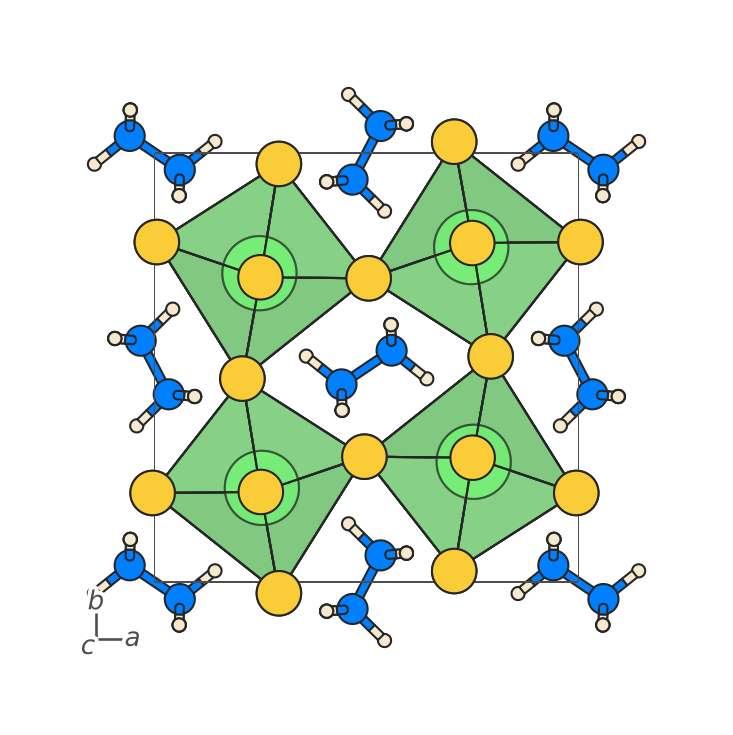

In [6]:
from hofmann import StructureScene, BondSpec, PolyhedronSpec
from pymatgen.core import Structure

structure = Structure.from_file("../01_hzzrs3/relax-ps/CONTCAR")

bonds = [
    BondSpec(species=('S', 'Zr'), min_length=0.0, max_length=2.9, radius=0.1, colour=0.5),
    BondSpec(species=('N', 'N'), min_length=0.0, max_length=1.9, radius=0.1, colour=0.5),
    BondSpec(species=('H', 'N'), min_length=0.0, max_length=1.2, radius=0.1, colour=0.5)
]
spec = PolyhedronSpec(
    centre="Zr",
    colour=(0.5, 1.0, 0.5),
    alpha=0.3,
)
scene = StructureScene.from_pymatgen(structure, bonds, polyhedra=[spec], pbc=True, pbc_padding=2)
scene.atom_styles["Zr"].colour = (0.5, 1.0, 0.5)
scene.atom_styles["N"].colour = (0.0, 0.5, 1.0)
fig = scene.render_mpl()
